# some libraries and function definitions

In [4]:
# refactored_medmnist_workflow.py

from __future__ import annotations

import copy
import math
import random
import subprocess
import sys
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader
from torchvision import transforms


# =========================
# Optional dependency setup
# =========================
def ensure_package(package_name: str) -> None:
    # Install a package if it's not already available.
    try:
        __import__(package_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])


ensure_package("medmnist")

try:
    ensure_package("skdim")
    import skdim  # type: ignore

    HAS_SKDIM = True
except Exception:
    HAS_SKDIM = False

import medmnist
from medmnist import INFO


# =========================
# Configuration
# =========================
@dataclass
class Config:
    dataset_flag: str = "bloodmnist"
    batch_size: int = 128
    probe_batch_size: int = 256
    learning_rate: float = 1e-3
    num_epochs: int = 20
    random_seed: int = 42


# =========================
# Model
# =========================
class SimpleMedMNISTCNN(nn.Module):
    def __init__(self, in_channels: int, n_classes: int, input_hw: tuple[int, int] = (28, 28)) -> None:
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 28 -> 14
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 14 -> 7
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 7 -> 3
        )

        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, *input_hw)
            flat_dim = int(np.prod(self.features(dummy).shape[1:]))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 128),
            nn.LeakyReLU(),
            nn.Linear(128, 128),
            nn.LeakyReLU(),
            nn.Linear(128, n_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


# =========================
# Core utilities
# =========================
def set_seed(seed: int) -> None:
    # Set random seeds for reproducibility across numpy, torch, and cuda.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def prepare_targets(y: torch.Tensor | np.ndarray) -> torch.Tensor:
    # Convert targets to long tensor format, flattening to 1D if needed.
    if isinstance(y, np.ndarray):
        y = torch.from_numpy(y)
    return y.view(-1).long()


def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    # Compute accuracy by comparing argmax predictions to ground truth labels.
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
) -> tuple[float, float]:
    # Train model for one epoch and return average loss and accuracy.
    model.train()
    loss_sum, acc_sum, n = 0.0, 0.0, 0

    for x, y in loader:
        x = x.to(device)
        y = prepare_targets(y).to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        acc_sum += accuracy_from_logits(logits, y)
        n += 1

    return loss_sum / max(n, 1), acc_sum / max(n, 1)


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device) -> tuple[float, float]:
    # Evaluate model on loader without computing gradients, returning loss and accuracy.
    model.eval()
    loss_sum, acc_sum, n = 0.0, 0.0, 0

    for x, y in loader:
        x = x.to(device)
        y = prepare_targets(y).to(device)

        logits = model(x)
        loss = criterion(logits, y)

        loss_sum += loss.item()
        acc_sum += accuracy_from_logits(logits, y)
        n += 1

    return loss_sum / max(n, 1), acc_sum / max(n, 1)


@torch.no_grad()
def evaluate_model_directly(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    class_names: list[str] | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    # Evaluate model, compute metrics, and display confusion matrix; return true labels, predictions, and logits.
    model.eval()
    y_true_all, y_pred_all, logits_all = [], [], []

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_true = y_batch.view(-1).cpu().numpy()

        logits = model(x_batch)
        y_pred = logits.argmax(dim=1).cpu().numpy()

        y_true_all.append(y_true)
        y_pred_all.append(y_pred)
        logits_all.append(logits.cpu().numpy())

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)
    logits = np.concatenate(logits_all)

    print("\nDirect model metrics")
    print("--------------------")
    print("Accuracy         :", round(accuracy_score(y_true, y_pred), 4))
    print("Balanced accuracy:", round(balanced_accuracy_score(y_true, y_pred), 4))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, xticks_rotation=90, colorbar=True)
    plt.title("Direct CNN confusion matrix")
    plt.tight_layout()
    plt.show()

    return y_true, y_pred, logits


# =========================
# Representation functions
# =========================
def extract_raw_input_matrix(loader: DataLoader, max_samples: int | None = None) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    # Extract raw input pixels (flattened), raw tensors, and labels from dataloader.
    all_x_raw, all_x_flat, all_y = [], [], []
    seen = 0

    for x_batch, y_batch in loader:
        x_raw = x_batch.detach().cpu()
        x_flat = torch.flatten(x_raw, start_dim=1)
        y = y_batch.view(-1).detach().cpu()

        all_x_raw.append(x_raw)
        all_x_flat.append(x_flat)
        all_y.append(y)

        seen += x_batch.size(0)
        if max_samples is not None and seen >= max_samples:
            break

    X_raw = torch.cat(all_x_raw, dim=0)
    X_flat = torch.cat(all_x_flat, dim=0)
    y = torch.cat(all_y, dim=0)

    if max_samples is not None:
        X_raw = X_raw[:max_samples]
        X_flat = X_flat[:max_samples]
        y = y[:max_samples]

    return X_raw.numpy(), X_flat.numpy(), y.numpy()


def run_pca(X: np.ndarray, n_components: int = 2, standardize: bool = True) -> tuple[np.ndarray, PCA, StandardScaler | None]:
    # Apply PCA to data (optionally standardized) and return transformed data, PCA object, and scaler.
    if standardize:
        scaler = StandardScaler()
        X_in = scaler.fit_transform(X)
    else:
        scaler = None
        X_in = X

    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_in)
    return X_pca, pca, scaler


def plot_pca_scatter(
    X_pca: np.ndarray,
    y: np.ndarray,
    pca: PCA,
    title: str,
    class_names: list[str] | None = None,
) -> None:
    # Visualize PCA-reduced data as a 2D scatter plot with class labels and variance explained.
    plt.figure(figsize=(12, 5))
    sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=8, alpha=0.75, cmap="tab10")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var.)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var.)")
    plt.title(title)

    if class_names is not None:
        cbar = plt.colorbar(sc)
        cbar.set_ticks(np.arange(len(class_names)))
        cbar.set_ticklabels(class_names)

    plt.tight_layout()
    plt.show()


@torch.no_grad()
def extract_representations(
    model: SimpleMedMNISTCNN,
    loader: DataLoader,
    device: torch.device,
    rep: str = "penultimate",
) -> tuple[np.ndarray, np.ndarray]:
    # Extract intermediate or final representations from model (penultimate, logits, or conv_flat) and labels.
    model.eval()
    all_Z, all_y = [], []

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch_np = y_batch.view(-1).cpu().numpy()

        if rep == "penultimate":
            h = model.features(x_batch)
            z = model.classifier[:5](h)
        elif rep == "logits":
            z = model(x_batch)
        elif rep == "conv_flat":
            h = model.features(x_batch)
            z = torch.flatten(h, start_dim=1)
        else:
            raise ValueError("rep must be one of: 'penultimate', 'logits', 'conv_flat'.")

        all_Z.append(z.detach().cpu().numpy())
        all_y.append(y_batch_np)

    return np.concatenate(all_Z, axis=0), np.concatenate(all_y, axis=0)


def summarize_representation(Z: np.ndarray, y: np.ndarray, name: str) -> None:
    # Print statistics about representation quality: variance, silhouette score, and nearest-centroid accuracy.
    print(f"\n{name}")
    print("-" * len(name))
    print("Shape:", Z.shape)

    Z_scaled = StandardScaler().fit_transform(Z)
    pca = PCA().fit(Z_scaled)

    print("PC1 variance:", round(float(pca.explained_variance_ratio_[0]), 4))
    if Z.shape[1] >= 2:
        print("PC1+PC2 variance:", round(float(pca.explained_variance_ratio_[:2].sum()), 4))

    unique, counts = np.unique(y, return_counts=True)
    if len(unique) > 1 and np.min(counts) > 1:
        print("Silhouette score:", round(float(silhouette_score(Z_scaled, y)), 4))
    else:
        print("Silhouette score: skipped")

    centroids = np.stack([Z_scaled[y == cls].mean(axis=0) for cls in unique], axis=0)
    dists = np.linalg.norm(Z_scaled[:, None, :] - centroids[None, :, :], axis=2)
    pred_labels = unique[np.argmin(dists, axis=1)]
    print("Nearest-centroid acc:", round(float(accuracy_score(y, pred_labels)), 4))


def linear_probe(train_Z: np.ndarray, train_y: np.ndarray, test_Z: np.ndarray, test_y: np.ndarray) -> LogisticRegression:
    # Train logistic regression on representations and evaluate train/test accuracy; assess representation quality.
    scaler = StandardScaler()
    train_Z_scaled = scaler.fit_transform(train_Z)
    test_Z_scaled = scaler.transform(test_Z)

    clf = LogisticRegression(max_iter=2000, n_jobs=-1, multi_class="auto")
    clf.fit(train_Z_scaled, train_y)

    train_acc = accuracy_score(train_y, clf.predict(train_Z_scaled))
    test_acc = accuracy_score(test_y, clf.predict(test_Z_scaled))

    print("\nLinear probe")
    print("------------")
    print("Train accuracy:", round(float(train_acc), 4))
    print("Test accuracy :", round(float(test_acc), 4))
    return clf


def estimate_intrinsic_dimension(Z: np.ndarray, name: str, k_list: list[int] | None = None) -> dict[str, float]:
    # Estimate intrinsic dimensionality using TwoNN, MLE, and TLE methods with varying k values.
    k_list = k_list or [10, 20, 30, 50]
    print(f"\n{name}")
    print("-" * len(name))
    print("Input shape:", Z.shape)

    if not HAS_SKDIM:
        print("skdim unavailable: skipped")
        return {}

    Z_scaled = StandardScaler().fit_transform(Z)
    results: dict[str, float] = {}

    try:
        d_twonn = float(skdim.id.TwoNN().fit_transform(Z_scaled))
        results["TwoNN"] = d_twonn
        print("TwoNN:", round(d_twonn, 2))
    except Exception as e:
        print("TwoNN failed:", e)

    for k in k_list:
        print(f"\nk = {k}")
        try:
            d_mle = float(skdim.id.MLE(K=k).fit_transform(Z_scaled))
            results[f"MLE_k{k}"] = d_mle
            print("MLE :", round(d_mle, 2))
        except Exception as e:
            print("MLE failed:", e)

        try:
            d_tle = float(skdim.id.TLE().fit_transform(Z_scaled, n_neighbors=k))
            results[f"TLE_k{k}"] = d_tle
            print("TLE :", round(d_tle, 2))
        except Exception as e:
            print("TLE failed:", e)

    return results


# workflow for a MedMINST data:

Using downloaded and verified file: /home/tiamheydari/.medmnist/bloodmnist.npz
Using downloaded and verified file: /home/tiamheydari/.medmnist/bloodmnist.npz
Using downloaded and verified file: /home/tiamheydari/.medmnist/bloodmnist.npz
Epoch 01/20 | train loss: 1.6094 | train acc: 0.3711 | val loss: 1.1676 | val acc: 0.5227
Epoch 02/20 | train loss: 0.9911 | train acc: 0.6112 | val loss: 0.8123 | val acc: 0.6773
Epoch 03/20 | train loss: 0.7988 | train acc: 0.6916 | val loss: 0.7042 | val acc: 0.7204
Epoch 04/20 | train loss: 0.7303 | train acc: 0.7182 | val loss: 0.6894 | val acc: 0.7260
Epoch 05/20 | train loss: 0.6992 | train acc: 0.7307 | val loss: 0.6331 | val acc: 0.7565
Epoch 06/20 | train loss: 0.6568 | train acc: 0.7495 | val loss: 0.6186 | val acc: 0.7537
Epoch 07/20 | train loss: 0.6357 | train acc: 0.7555 | val loss: 0.6566 | val acc: 0.7511
Epoch 08/20 | train loss: 0.5997 | train acc: 0.7724 | val loss: 0.5447 | val acc: 0.7920
Epoch 09/20 | train loss: 0.5638 | train ac

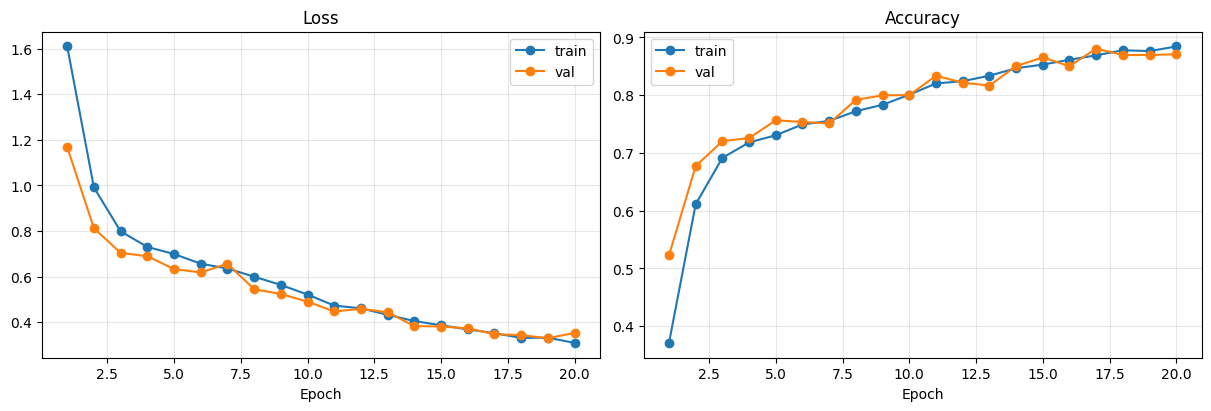


Direct model metrics
--------------------
Accuracy         : 0.8655
Balanced accuracy: 0.8369


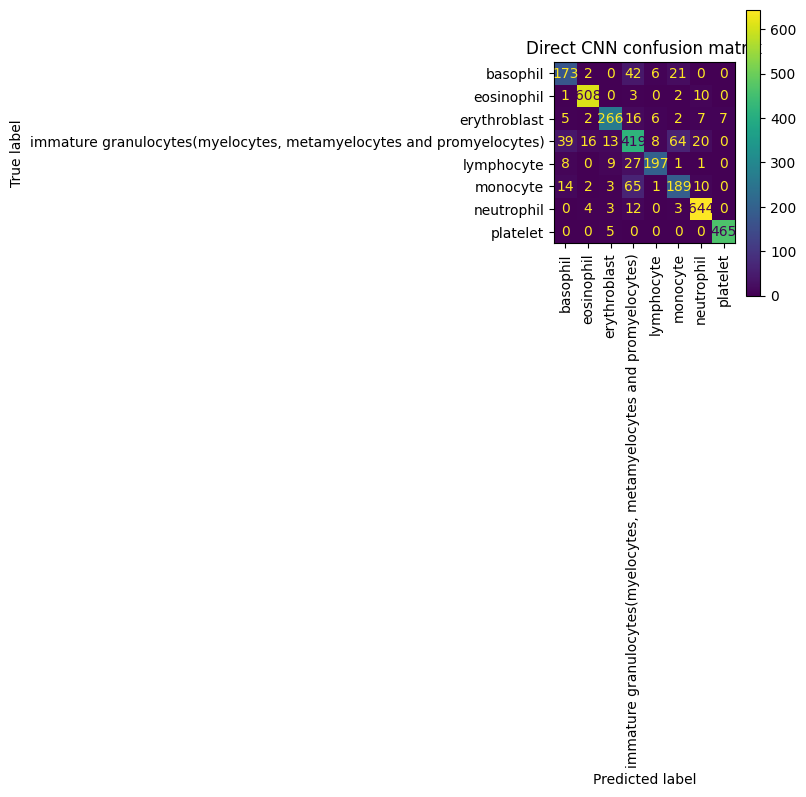

In [3]:


cfg = Config()
set_seed(cfg.random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#print("device:", device)
#print("torch version:", torch.__version__)
#print("medmnist version:", medmnist.__version__)

#2: load dataset  ========================================================================
info = INFO[cfg.dataset_flag]
n_channels = info["n_channels"]
n_classes = len(info["label"])
class_names = list(info["label"].values())
DataClass = getattr(medmnist, info["python_class"])

#print("\nDataset metadata")
#print("----------------")
#print("dataset flag:", cfg.dataset_flag)
#print("task        :", info["task"])
#print("n_classes   :", n_classes)
#print("n_channels  :", n_channels)

transform = transforms.Compose([transforms.ToTensor()])
train_dataset = DataClass(split="train", transform=transform, download=True)
val_dataset = DataClass(split="val", transform=transform, download=True)
test_dataset = DataClass(split="test", transform=transform, download=True)


#3: load into dataloader  ========================================================================
train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False)

train_loader_probe = DataLoader(train_dataset, batch_size=cfg.probe_batch_size, shuffle=False)
test_loader_probe = DataLoader(test_dataset, batch_size=cfg.probe_batch_size, shuffle=False)

#4: define and initialize model ========================================================================
sample_x, _ = train_dataset[0]
_, H, W = sample_x.shape
model = SimpleMedMNISTCNN(n_channels, n_classes, input_hw=(H, W)).to(device)

#5: define loss function ========================================================================
criterion = nn.CrossEntropyLoss()

#6: define optimizer and trainig loops ========================================================================
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate)
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = -1.0
best_state = None

#7: train model ========================================================================
for epoch in range(1, cfg.num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch:02d}/{cfg.num_epochs} | "
        f"train loss: {train_loss:.4f} | train acc: {train_acc:.4f} | "
        f"val loss: {val_loss:.4f} | val acc: {val_acc:.4f}"
    )

if best_state is not None:
    model.load_state_dict(best_state)

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print("\nFinal test")
print("----------")
print(f"Loss: {test_loss:.4f}")
print(f"Acc : {test_acc:.4f}")

epochs = np.arange(1, cfg.num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(epochs, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs, history["val_loss"], marker="o", label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["train_acc"], marker="o", label="train")
axes[1].plot(epochs, history["val_acc"], marker="o", label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.show()

_ = evaluate_model_directly(model, test_loader, device, class_names=class_names)

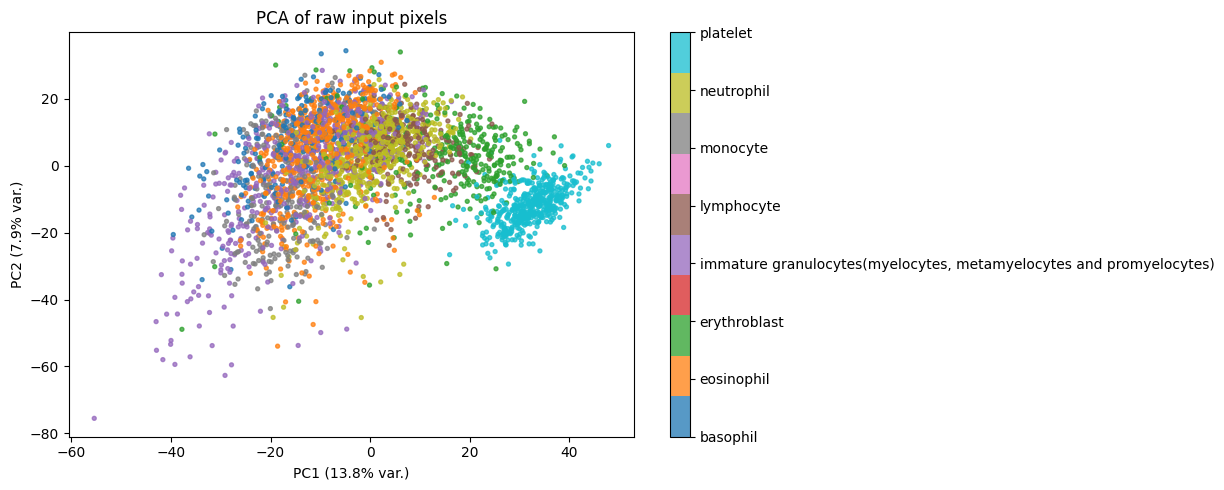


Raw input pixels [N, c*h*w]
---------------------------
Input shape: (3421, 2352)
TwoNN: 30.12

k = 10
MLE : 28.1
TLE : 28.52

k = 20
MLE : 28.1
TLE : 23.82

k = 30
MLE : 28.1
TLE : 22.03

k = 50
MLE : 28.1
TLE : 20.31

Penultimate representation [N, 128]
-----------------------------------
Shape: (3421, 128)
PC1 variance: 0.3967
PC1+PC2 variance: 0.6728
Silhouette score: 0.3222
Nearest-centroid acc: 0.8275


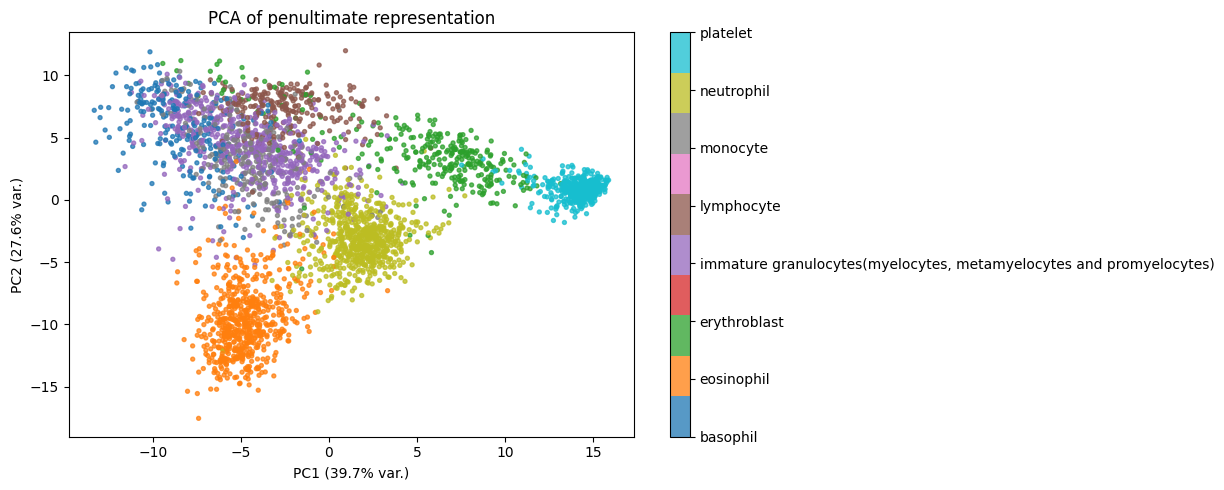


Linear probe
------------
Train accuracy: 0.9068
Test accuracy : 0.8758

Penultimate representation [N, 128]
-----------------------------------
Input shape: (3421, 128)
TwoNN: 6.76

k = 10
MLE : 6.0
TLE : 7.03

k = 20
MLE : 6.0
TLE : 5.94

k = 30
MLE : 6.0
TLE : 5.56

k = 50
MLE : 6.0
TLE : 5.1

Final logits [N, n_classes]
---------------------------
Shape: (3421, 8)
PC1 variance: 0.51
PC1+PC2 variance: 0.8191
Silhouette score: 0.3652
Nearest-centroid acc: 0.8281


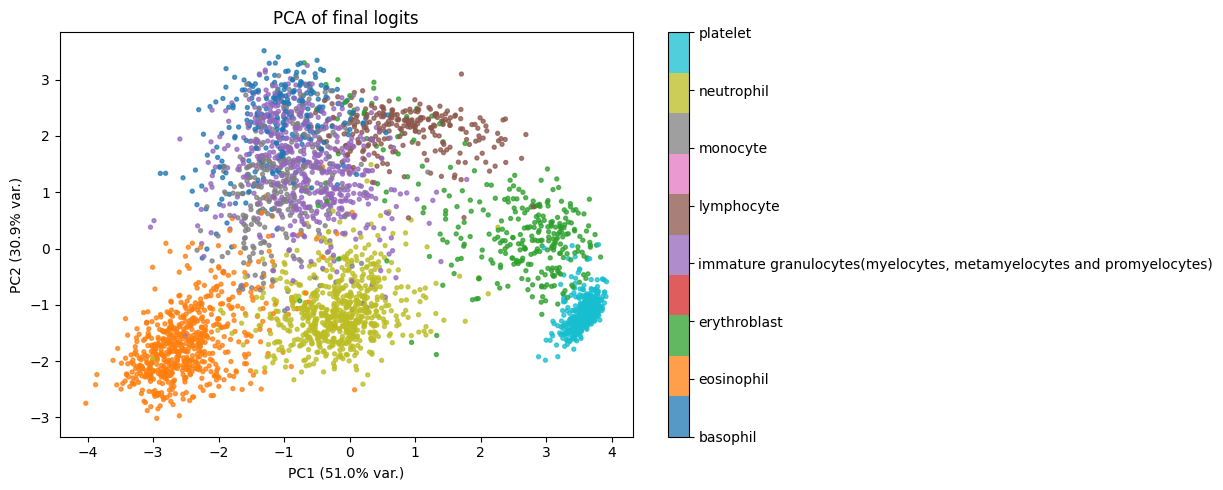


Final logits [N, n_classes]
---------------------------
Input shape: (3421, 8)
TwoNN: 4.77

k = 10
MLE : 4.68
TLE : 5.47

k = 20
MLE : 4.68
TLE : 4.7

k = 30
MLE : 4.68
TLE : 4.41

k = 50
MLE : 4.68
TLE : 4.11


In [5]:

#Probing the raw input representation========================
X_raw, X_flat, y_raw = extract_raw_input_matrix(test_loader_probe)
X_pca_raw, pca_raw, _ = run_pca(X_flat, n_components=2, standardize=True)
plot_pca_scatter(X_pca_raw, y_raw, pca_raw, "PCA of raw input pixels", class_names)
_ = estimate_intrinsic_dimension(X_flat, "Raw input pixels [N, c*h*w]")


#Probing the internal Reprensetation of latent space (penultimate)========================
Z_train_pen, y_train = extract_representations(model, train_loader_probe, device, rep="penultimate")
Z_test_pen, y_test = extract_representations(model, test_loader_probe, device, rep="penultimate")
summarize_representation(Z_test_pen, y_test, "Penultimate representation [N, 128]")
Z_pca_pen, pca_pen, _ = run_pca(Z_test_pen, n_components=2, standardize=True)
plot_pca_scatter(Z_pca_pen, y_test, pca_pen, "PCA of penultimate representation", class_names)
_ = linear_probe(Z_train_pen, y_train, Z_test_pen, y_test) #function evaluates how well a linear classifier can perform on learned representations
_ = estimate_intrinsic_dimension(Z_test_pen, "Penultimate representation [N, 128]")


#Probing the final logits of the mode========================
Z_test_logits, y_test_logits = extract_representations(model, test_loader_probe, device, rep="logits")
summarize_representation(Z_test_logits, y_test_logits, "Final logits [N, n_classes]")
Z_pca_log, pca_log, _ = run_pca(Z_test_logits, n_components=2, standardize=True)
plot_pca_scatter(Z_pca_log, y_test_logits, pca_log, "PCA of final logits", class_names)
_ = estimate_intrinsic_dimension(Z_test_logits, "Final logits [N, n_classes]")

# Null-hypothesis workflow: data vs architecture contributions

This section tests whether low-dimensional structure in the penultimate representation comes from:
1. **Data structure** (real images vs noise),
2. **Architecture bias** (untrained CNN),
3. **Learning signal** (true labels vs shuffled labels).

In [6]:
# =========================
# Null-hypothesis experiment setup
# =========================
from torch.utils.data import Dataset


class LabelShuffledDataset(Dataset):
    # Keep images unchanged but randomly permute labels.
    def __init__(self, base_dataset, seed: int = 42):
        self.base = base_dataset
        rng = np.random.default_rng(seed)

        y = []
        for i in range(len(base_dataset)):
            _, yi = base_dataset[i]
            y.append(int(np.array(yi).reshape(-1)[0]))

        self.shuffled_labels = rng.permutation(np.array(y, dtype=np.int64))

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, _ = self.base[idx]
        y = torch.tensor([int(self.shuffled_labels[idx])], dtype=torch.long)
        return x, y


class GaussianNoiseDataset(Dataset):
    # Generate synthetic images with matched mean/std and random labels.
    def __init__(self, n_samples: int, image_shape: tuple[int, int, int], n_classes: int, mean: torch.Tensor, std: torch.Tensor, seed: int = 42):
        self.n_samples = n_samples
        self.n_classes = n_classes

        g = torch.Generator().manual_seed(seed)
        c, h, w = image_shape

        noise = torch.randn(n_samples, c, h, w, generator=g)
        mean = mean.view(1, c, 1, 1)
        std = std.view(1, c, 1, 1)
        self.x = (noise * std + mean).clamp(0.0, 1.0)
        self.y = torch.randint(low=0, high=n_classes, size=(n_samples,), generator=g)

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx].view(1)


def estimate_channel_stats(dataset):
    # Estimate per-channel mean and std from a dataset.
    loader = DataLoader(dataset, batch_size=512, shuffle=False)
    n_total = 0
    channel_sum = None
    channel_sq_sum = None

    for x, _ in loader:
        b = x.size(0)
        x_flat = x.view(b, x.size(1), -1)

        s = x_flat.sum(dim=(0, 2))
        sq = (x_flat**2).sum(dim=(0, 2))

        channel_sum = s if channel_sum is None else channel_sum + s
        channel_sq_sum = sq if channel_sq_sum is None else channel_sq_sum + sq
        n_total += b * x_flat.size(2)

    mean = channel_sum / n_total
    var = channel_sq_sum / n_total - mean**2
    std = torch.sqrt(torch.clamp(var, min=1e-8))
    return mean, std


def fit_model_for_probe(train_loader_local, val_loader_local, seed: int, epochs: int = 8):
    # Train a fresh model and return best-validation checkpoint.
    set_seed(seed)
    m = SimpleMedMNISTCNN(n_channels, n_classes, input_hw=(H, W)).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=cfg.learning_rate)
    crit = nn.CrossEntropyLoss()

    best_acc = -1.0
    best_state_local = None

    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(m, train_loader_local, opt, crit, device)
        va_loss, va_acc = evaluate(m, val_loader_local, crit, device)

        if va_acc > best_acc:
            best_acc = va_acc
            best_state_local = copy.deepcopy(m.state_dict())

        print(f"Epoch {ep:02d}/{epochs} | train acc: {tr_acc:.4f} | val acc: {va_acc:.4f}")

    if best_state_local is not None:
        m.load_state_dict(best_state_local)
    return m


def pick_single_id(id_results: dict[str, float]) -> float:
    # Choose a single ID value for summary (TwoNN preferred).
    if "TwoNN" in id_results:
        return float(id_results["TwoNN"])
    if len(id_results) > 0:
        return float(next(iter(id_results.values())))
    return float("nan")


def run_penultimate_null_experiment(tag: str, model_for_rep, train_loader_rep, test_loader_rep):
    # Extract penultimate reps, run linear probe, and estimate intrinsic dimension.
    print(f"\n=== {tag} ===")
    Ztr, ytr = extract_representations(model_for_rep, train_loader_rep, device, rep="penultimate")
    Zte, yte = extract_representations(model_for_rep, test_loader_rep, device, rep="penultimate")

    summarize_representation(Zte, yte, f"{tag} penultimate")
    _ = linear_probe(Ztr, ytr, Zte, yte)
    id_dict = estimate_intrinsic_dimension(Zte, f"{tag} penultimate")
    return {
        "tag": tag,
        "id_penultimate": pick_single_id(id_dict),
    }


# =========================
# Build data variants
# =========================
mean_c, std_c = estimate_channel_stats(train_dataset)
image_shape = (n_channels, H, W)

shuffled_train_dataset = LabelShuffledDataset(train_dataset, seed=cfg.random_seed)
shuffled_val_dataset = LabelShuffledDataset(val_dataset, seed=cfg.random_seed + 1)

noise_train_dataset = GaussianNoiseDataset(
    n_samples=len(train_dataset),
    image_shape=image_shape,
    n_classes=n_classes,
    mean=mean_c,
    std=std_c,
    seed=cfg.random_seed,
)
noise_test_dataset = GaussianNoiseDataset(
    n_samples=len(test_dataset),
    image_shape=image_shape,
    n_classes=n_classes,
    mean=mean_c,
    std=std_c,
    seed=cfg.random_seed + 1,
)

# Loaders
real_train_probe = DataLoader(train_dataset, batch_size=cfg.probe_batch_size, shuffle=False)
real_test_probe = DataLoader(test_dataset, batch_size=cfg.probe_batch_size, shuffle=False)

shuffle_train_loader = DataLoader(shuffled_train_dataset, batch_size=cfg.batch_size, shuffle=True)
shuffle_val_loader = DataLoader(shuffled_val_dataset, batch_size=cfg.batch_size, shuffle=False)
shuffle_train_probe = DataLoader(shuffled_train_dataset, batch_size=cfg.probe_batch_size, shuffle=False)
shuffle_test_probe = DataLoader(LabelShuffledDataset(test_dataset, seed=cfg.random_seed + 2), batch_size=cfg.probe_batch_size, shuffle=False)

noise_train_loader = DataLoader(noise_train_dataset, batch_size=cfg.batch_size, shuffle=True)
noise_val_loader = DataLoader(noise_test_dataset, batch_size=cfg.batch_size, shuffle=False)
noise_train_probe = DataLoader(noise_train_dataset, batch_size=cfg.probe_batch_size, shuffle=False)
noise_test_probe = DataLoader(noise_test_dataset, batch_size=cfg.probe_batch_size, shuffle=False)

# =========================
# Run conditions
# =========================
results = []

# A) Real data + untrained model (architecture-only effect)
untrained_real_model = SimpleMedMNISTCNN(n_channels, n_classes, input_hw=(H, W)).to(device)
results.append(run_penultimate_null_experiment("Real + Untrained", untrained_real_model, real_train_probe, real_test_probe))

# B) Real data + trained true labels
results.append(run_penultimate_null_experiment("Real + Trained (True Labels)", model, real_train_probe, real_test_probe))

# C) Real data + trained shuffled labels
shuffle_model = fit_model_for_probe(shuffle_train_loader, shuffle_val_loader, seed=cfg.random_seed + 10, epochs=8)
results.append(run_penultimate_null_experiment("Real + Trained (Shuffled Labels)", shuffle_model, shuffle_train_probe, shuffle_test_probe))

# D) Noise data + untrained model (data-null baseline)
untrained_noise_model = SimpleMedMNISTCNN(n_channels, n_classes, input_hw=(H, W)).to(device)
results.append(run_penultimate_null_experiment("Noise + Untrained", untrained_noise_model, noise_train_probe, noise_test_probe))

# E) Noise data + trained model
noise_model = fit_model_for_probe(noise_train_loader, noise_val_loader, seed=cfg.random_seed + 20, epochs=8)
results.append(run_penultimate_null_experiment("Noise + Trained", noise_model, noise_train_probe, noise_test_probe))

# =========================
# Summary table + effect decomposition
# =========================
print("\n\nSummary of intrinsic dimensionality (penultimate)")
print("=" * 60)
for r in results:
    print(f"{r['tag']:<35} ID ≈ {r['id_penultimate']:.3f}")

id_map = {r["tag"]: r["id_penultimate"] for r in results}

# Architecture compression on real data: raw -> untrained penultimate
id_raw_real = pick_single_id(estimate_intrinsic_dimension(X_flat, "Raw real input [test set]"))
id_real_untrained = id_map.get("Real + Untrained", np.nan)
id_real_trained = id_map.get("Real + Trained (True Labels)", np.nan)
id_real_shuffle = id_map.get("Real + Trained (Shuffled Labels)", np.nan)
id_noise_untrained = id_map.get("Noise + Untrained", np.nan)
id_noise_trained = id_map.get("Noise + Trained", np.nan)

delta_arch_real = id_raw_real - id_real_untrained
delta_learn_real = id_real_untrained - id_real_trained
delta_label_signal = id_real_shuffle - id_real_trained
delta_data_structure_untrained = id_noise_untrained - id_real_untrained
delta_data_structure_trained = id_noise_trained - id_real_trained

print("\nEffect decomposition (lower ID means more compression)")
print("-" * 60)
print(f"Architecture effect on real data   (raw - untrained): {delta_arch_real:.3f}")
print(f"Learning effect on real data      (untrained - trained true): {delta_learn_real:.3f}")
print(f"Label-information effect          (trained shuffled - trained true): {delta_label_signal:.3f}")
print(f"Data-structure effect (untrained) (noise untrained - real untrained): {delta_data_structure_untrained:.3f}")
print(f"Data-structure effect (trained)   (noise trained - real trained): {delta_data_structure_trained:.3f}")

print("\nInterpretation guide:")
print("- Large architecture effect => CNN inductive bias compresses representations even before training.")
print("- Large learning effect => supervision further organizes/compresses latent space.")
print("- Large label-information effect => true labels add meaningful structure beyond memorization.")
print("- Large data-structure effects => real image statistics drive low-dimensional structure.")


=== Real + Untrained ===

Real + Untrained penultimate
----------------------------
Shape: (3421, 128)
PC1 variance: 0.2616
PC1+PC2 variance: 0.376
Silhouette score: 0.0332
Nearest-centroid acc: 0.6209

Linear probe
------------
Train accuracy: 0.7605
Test accuracy : 0.7483

Real + Untrained penultimate
----------------------------
Input shape: (3421, 128)
TwoNN: 20.82

k = 10
MLE : 18.71
TLE : 20.26

k = 20
MLE : 18.71
TLE : 17.02

k = 30
MLE : 18.71
TLE : 15.75

k = 50
MLE : 18.71
TLE : 14.44

=== Real + Trained (True Labels) ===

Real + Trained (True Labels) penultimate
----------------------------------------
Shape: (3421, 128)
PC1 variance: 0.3967
PC1+PC2 variance: 0.6728
Silhouette score: 0.3222
Nearest-centroid acc: 0.8275

Linear probe
------------
Train accuracy: 0.9068
Test accuracy : 0.8758

Real + Trained (True Labels) penultimate
----------------------------------------
Input shape: (3421, 128)
TwoNN: 6.76

k = 10
MLE : 6.0
TLE : 7.03

k = 20
MLE : 6.0
TLE : 5.94

k = 30
